In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#!pip install pmdarimab

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [3]:
stock_data = pd.read_csv('GoogleStockPrices.csv')
stock_data.head()

,Date,Open,High,Low,Close,Volume
0,2015-01-02 16:00:00,26.63,26.79,26.39,26.48,1327870
1,2015-01-05 16:00:00,26.36,26.40,25.89,25.97,2059119
2,2015-01-06 16:00:00,26.02,26.06,25.28,25.33,2731813
3,2015-01-07 16:00:00,25.55,25.57,25.18,25.26,2345875
4,2015-01-08 16:00:00,25.08,25.38,24.75,25.35,3662224


In [4]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2516 non-null   object 
 1   Open    2516 non-null   float64
 2   High    2516 non-null   float64
 3   Low     2516 non-null   float64
 4   Close   2516 non-null   float64
 5   Volume  2516 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 118.1+ KB


In [5]:
stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.date
stock_data.head()

,Date,Open,High,Low,Close,Volume
0,2015-01-02,26.63,26.79,26.39,26.48,1327870
1,2015-01-05,26.36,26.40,25.89,25.97,2059119
2,2015-01-06,26.02,26.06,25.28,25.33,2731813
3,2015-01-07,25.55,25.57,25.18,25.26,2345875
4,2015-01-08,25.08,25.38,24.75,25.35,3662224


In [6]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2516 non-null   object 
 1   Open    2516 non-null   float64
 2   High    2516 non-null   float64
 3   Low     2516 non-null   float64
 4   Close   2516 non-null   float64
 5   Volume  2516 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 118.1+ KB


In [7]:
stock_data.set_index('Date', inplace=True)
stock_data = stock_data.asfreq('B')
# Fill missing close prices
stock_data['Close'] = stock_data['Close'].ffill()
stock_data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,26.63,26.79,26.39,26.48,1327870.0
2015-01-05,26.36,26.40,25.89,25.97,2059119.0
2015-01-06,26.02,26.06,25.28,25.33,2731813.0
2015-01-07,25.55,25.57,25.18,25.26,2345875.0
2015-01-08,25.08,25.38,24.75,25.35,3662224.0


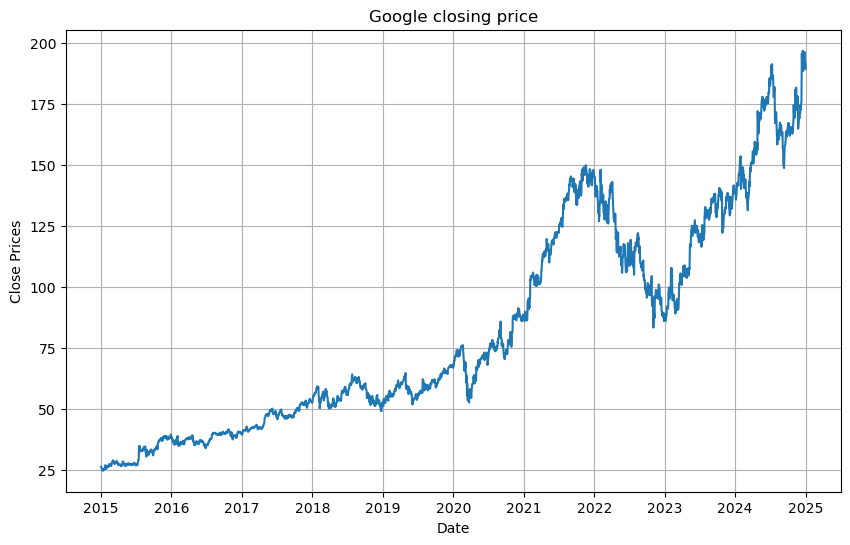

In [8]:
#plot close price
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Close Prices')
plt.plot(stock_data['Close'])
plt.title('Google closing price')
plt.show()

<Axes: ylabel='Density'>

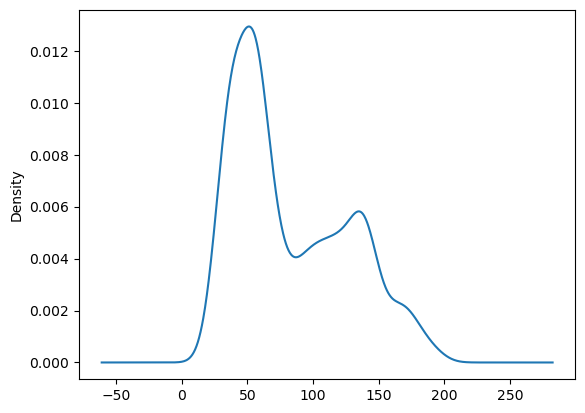

In [9]:
#Distribution of the dataset
df_close = stock_data['Close']
df_close.plot(kind='kde')

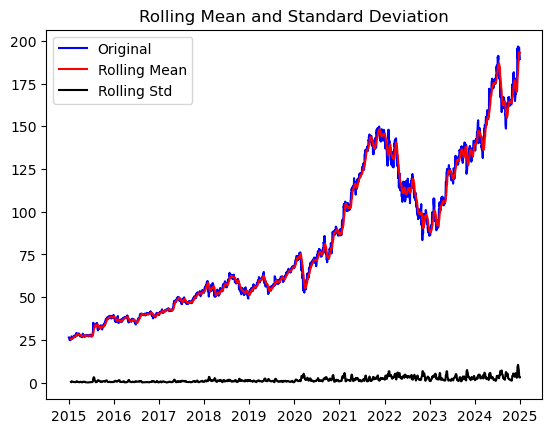

Results of dickey fuller test
Test Statistics                   0.647148
p-value                           0.988722
No. of lags used                 25.000000
Number of observations used    2582.000000
critical value (1%)              -3.432885
critical value (5%)              -2.862660
critical value (10%)             -2.567366
dtype: float64


In [10]:
#Test for staionarity
def test_stationarity(timeseries):
    #Determing rolling statistics
    rolmean = timeseries.rolling(12).mean()
    rolstd = timeseries.rolling(12).std()
    #Plot rolling statistics:
    plt.plot(timeseries, color='blue',label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.show(block=False)
    print("Results of dickey fuller test")
    adft = adfuller(timeseries,autolag='AIC')
    # output for dft will give us without defining what the values are.
    #hence we manually write what values does it explains using a for loop
    output = pd.Series(adft[0:4],index=['Test Statistics','p-value','No. of lags used','Number of observations used'])
    for key,values in adft[4].items():
        output['critical value (%s)'%key] =  values
    print(output)
test_stationarity(df_close)

<Figure size 640x480 with 0 Axes>

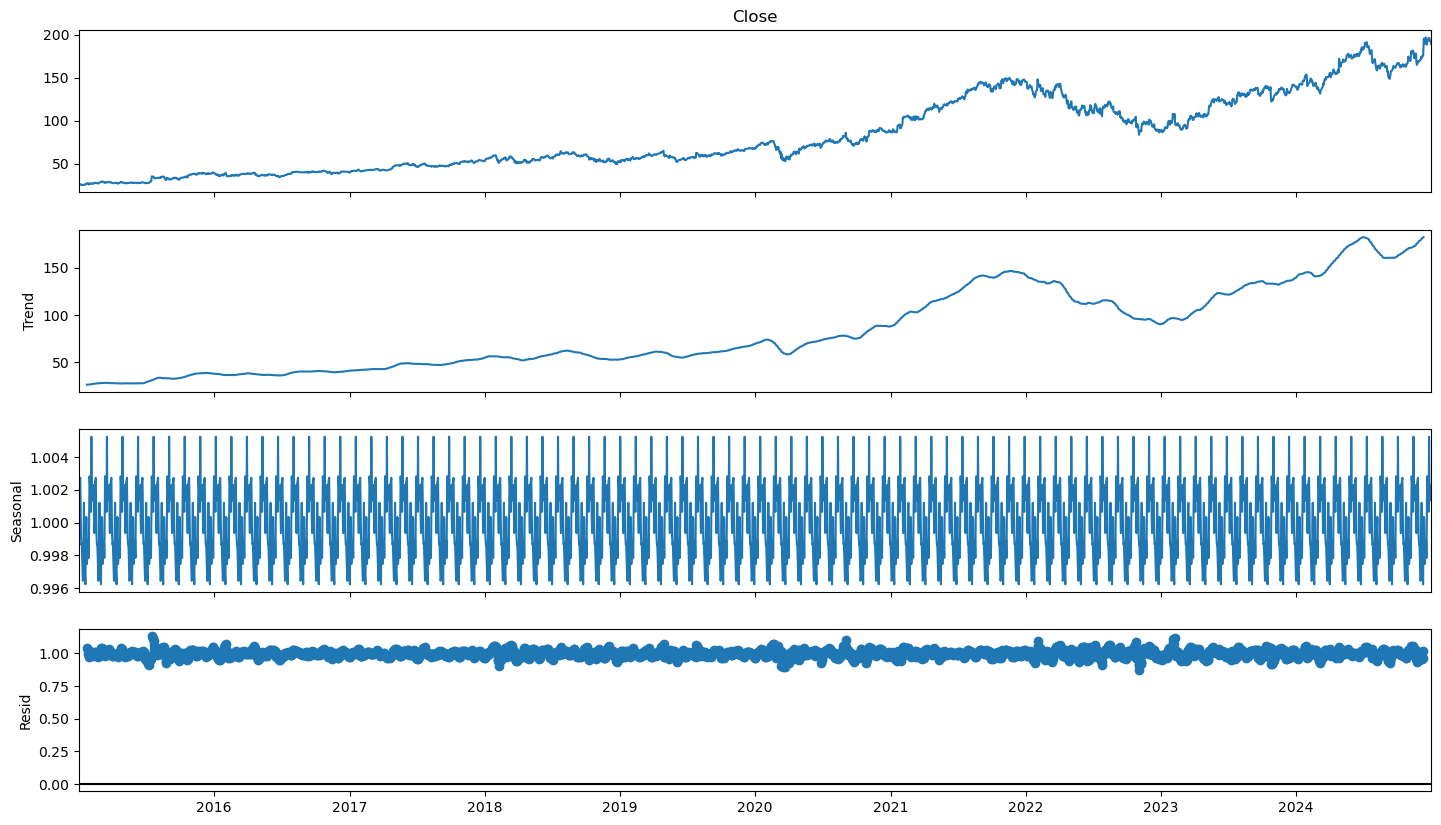

In [11]:
#To separate the trend and the seasonality from a time series,
# we can decompose the series using the following code.
result = seasonal_decompose(df_close, model='multiplicative', period = 30)
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(16, 9)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


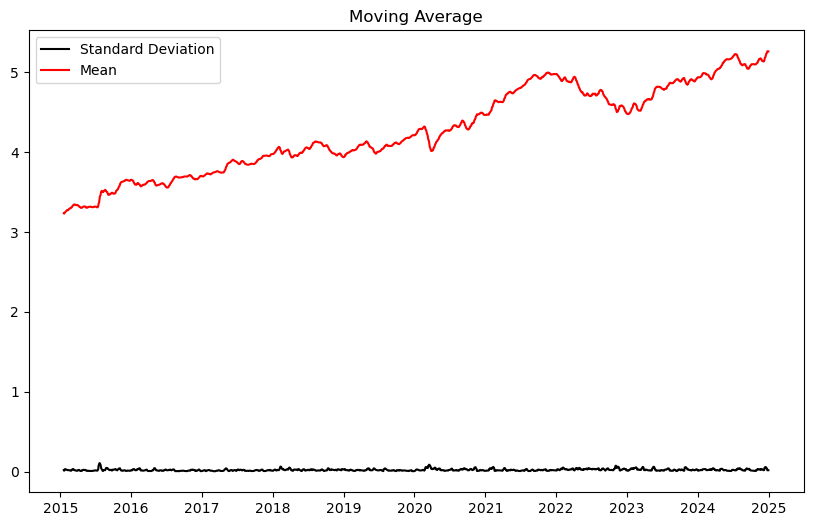

In [12]:
#if not stationary then eliminate trend
#Eliminate trend
from pylab import rcParams
rcParams['figure.figsize'] = 10, 6
df_log = np.log(df_close)
moving_avg = df_log.rolling(12).mean()
std_dev = df_log.rolling(12).std()
plt.legend(loc='best')
plt.title('Moving Average')
plt.plot(std_dev, color ="black", label = "Standard Deviation")
plt.plot(moving_avg, color="red", label = "Mean")
plt.legend()
plt.show()

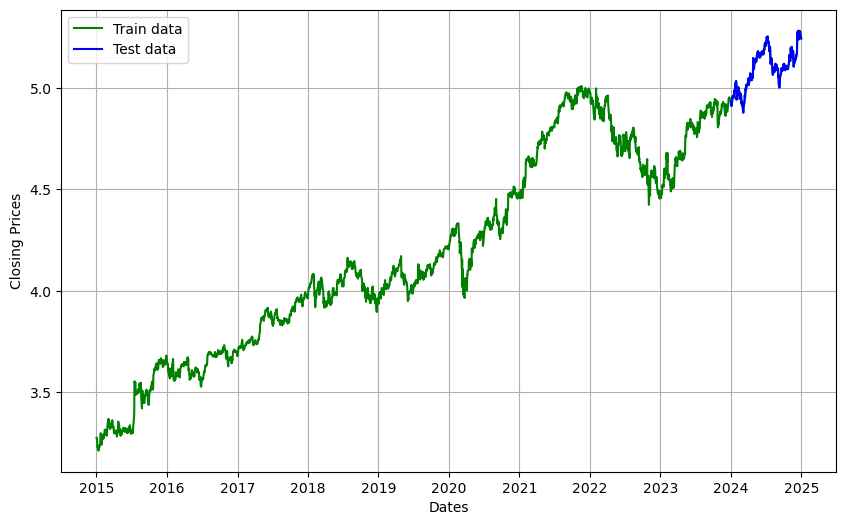

In [13]:
#split data into train and training set
train_data, test_data = df_log[3:int(len(df_log)*0.9)], df_log[int(len(df_log)*0.9):]
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(df_log, 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-12274.889, Time=1.18 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-12279.016, Time=0.76 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-12279.089, Time=0.88 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-12272.867, Time=0.56 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-12277.259, Time=1.92 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-12277.176, Time=1.77 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-12278.747, Time=4.95 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-12276.615, Time=0.68 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 12.733 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2344
Model:               SARIMAX(0, 1, 1)   Log Likelihood                6142.545
Date:                Sun, 10 May 2026   AIC                         -12279.089
Time:              

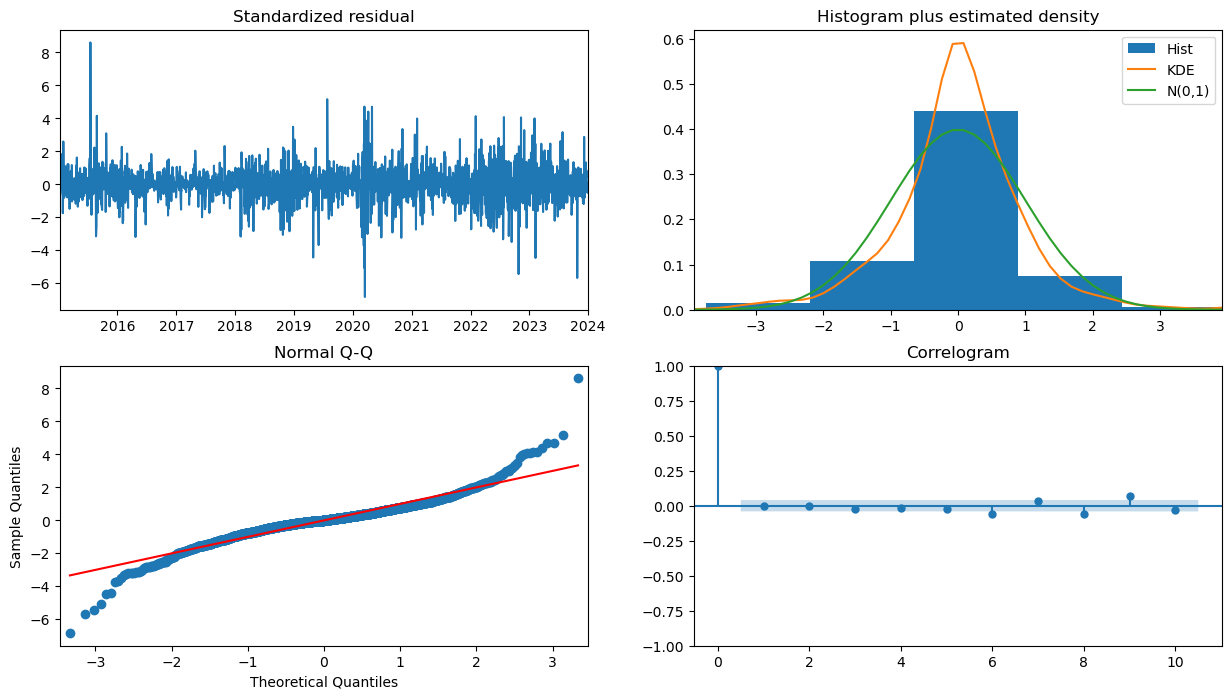

In [14]:
model_autoARIMA = auto_arima(train_data, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0,
                      D=0,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

In [15]:
#Modeling
# Build Model
model = ARIMA(train_data, order=(0,1,1))
fitted = model.fit()
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2344
Model:                 ARIMA(0, 1, 1)   Log Likelihood                6140.308
Date:                Sun, 10 May 2026   AIC                         -12276.615
Time:                        19:39:48   BIC                         -12265.097
Sample:                    01-07-2015   HQIC                        -12272.420
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0497      0.014     -3.561      0.000      -0.077      -0.022
sigma2         0.0003   4.42e-06     70.015      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   0.01   Jarque-

Date
2024-01-02    4.939435
2024-01-03    4.939435
2024-01-04    4.939435
2024-01-05    4.939435
2024-01-08    4.939435
Freq: B, Name: predicted_mean, dtype: float64


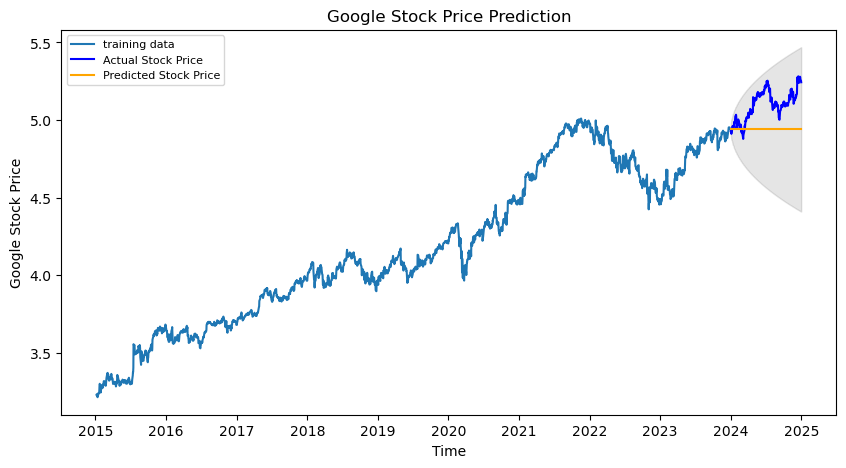

In [16]:
# Forecast
forecast_result = fitted.get_forecast(steps=len(test_data))

# Predicted values
fc = forecast_result.predicted_mean

# Confidence intervals
conf = forecast_result.conf_int()

# Convert forecast to series
fc_series = pd.Series(fc, index=test_data.index)

# Lower & upper bounds
lower_series = pd.Series(conf.iloc[:, 0], index=test_data.index)
upper_series = pd.Series(conf.iloc[:, 1], index=test_data.index)

print(fc_series.head())

# Plot
plt.figure(figsize=(10,5), dpi=100)
plt.plot(train_data, label='training data')
plt.plot(test_data, color = 'blue', label='Actual Stock Price')
plt.plot(fc_series, color = 'orange',label='Predicted Stock Price')
plt.fill_between(lower_series.index, lower_series, upper_series,
                 color='k', alpha=.10)
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [17]:
# report performance
mse = mean_squared_error(test_data, fc)
print('MSE: '+str(mse))
mae = mean_absolute_error(test_data, fc)
print('MAE: '+str(mae))
rmse = math.sqrt(mean_squared_error(test_data, fc))
print('RMSE: '+str(rmse))
mape = np.mean(np.abs(fc - test_data)/np.abs(test_data))
print('MAPE: '+str(mape))

MSE: 0.033200751509767666
MAE: 0.15839303079481634
RMSE: 0.18221073379405414
MAPE: 0.03077223368389953
